In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report
from sklearn import metrics
import warnings
warnings.filterwarnings('ignore')

In [55]:
df = pd.read_csv('archive/android_traffic.csv', sep=";")
df

,name,tcp_packets,dist_port_tcp,external_ips,vulume_bytes,udp_packets,tcp_urg_packet,source_app_packets,remote_app_packets,source_app_bytes,remote_app_bytes,duracion,avg_local_pkt_rate,avg_remote_pkt_rate,source_app_packets.1,dns_query_times,type
0,AntiVirus,36,6,3,3911,0,0,39,33,5100,4140,NaN,NaN,NaN,39,3,benign
1,AntiVirus,117,0,9,23514,0,0,128,107,26248,24358,NaN,NaN,NaN,128,11,benign
2,AntiVirus,196,0,6,24151,0,0,205,214,163887,24867,NaN,NaN,NaN,205,9,benign
3,AntiVirus,6,0,1,889,0,0,7,6,819,975,NaN,NaN,NaN,7,1,benign
4,AntiVirus,6,0,1,882,0,0,7,6,819,968,NaN,NaN,NaN,7,1,benign
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7840,Zsone,0,0,0,0,0,0,2,2,257,143,NaN,NaN,NaN,2,2,malicious
7841,Zsone,4,4,1,296,0,0,5,1,86,382,NaN,NaN,NaN,5,1,malicious
7842,Zsone,0,0,0,0,0,0,2,2,257,143,NaN,NaN,NaN,2,2,malicious
7843,Zsone,0,0,0,0,0,0,2,2,257,143,NaN,NaN,NaN,2,2,malicious


In [56]:
df.head(100)

,name,tcp_packets,dist_port_tcp,external_ips,vulume_bytes,udp_packets,tcp_urg_packet,source_app_packets,remote_app_packets,source_app_bytes,remote_app_bytes,duracion,avg_local_pkt_rate,avg_remote_pkt_rate,source_app_packets.1,dns_query_times,type
0,AntiVirus,36,6,3,3911,0,0,39,33,5100,4140,NaN,NaN,NaN,39,3,benign
1,AntiVirus,117,0,9,23514,0,0,128,107,26248,24358,NaN,NaN,NaN,128,11,benign
2,AntiVirus,196,0,6,24151,0,0,205,214,163887,24867,NaN,NaN,NaN,205,9,benign
3,AntiVirus,6,0,1,889,0,0,7,6,819,975,NaN,NaN,NaN,7,1,benign
4,AntiVirus,6,0,1,882,0,0,7,6,819,968,NaN,NaN,NaN,7,1,benign
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,AntiVirus,92,0,8,21675,0,0,103,92,21238,22535,NaN,NaN,NaN,103,11,benign
96,AntiVirus,26,26,2,6844,0,0,28,20,10612,6995,NaN,NaN,NaN,28,2,benign
97,AntiVirus,6,0,2,444,0,0,9,3,482,665,NaN,NaN,NaN,9,3,benign
98,AntiVirus,117,30,5,16518,0,0,129,95,11657,17448,NaN,NaN,NaN,129,12,benign


In [57]:
df.tail()

,name,tcp_packets,dist_port_tcp,external_ips,vulume_bytes,udp_packets,tcp_urg_packet,source_app_packets,remote_app_packets,source_app_bytes,remote_app_bytes,duracion,avg_local_pkt_rate,avg_remote_pkt_rate,source_app_packets.1,dns_query_times,type
7840,Zsone,0,0,0,0,0,0,2,2,257,143,NaN,NaN,NaN,2,2,malicious
7841,Zsone,4,4,1,296,0,0,5,1,86,382,NaN,NaN,NaN,5,1,malicious
7842,Zsone,0,0,0,0,0,0,2,2,257,143,NaN,NaN,NaN,2,2,malicious
7843,Zsone,0,0,0,0,0,0,2,2,257,143,NaN,NaN,NaN,2,2,malicious
7844,Zsone,0,0,0,0,0,0,2,2,257,143,NaN,NaN,NaN,2,2,malicious


In [58]:
df.size

133365

In [59]:
df.shape

(7845, 17)

In [60]:
df.columns

Index(['name', 'tcp_packets', 'dist_port_tcp', 'external_ips', 'vulume_bytes',
       'udp_packets', 'tcp_urg_packet', 'source_app_packets',
       'remote_app_packets', 'source_app_bytes', 'remote_app_bytes',
       'duracion', 'avg_local_pkt_rate', 'avg_remote_pkt_rate',
       'source_app_packets.1', 'dns_query_times', 'type'],
      dtype='object')

In [61]:
df['type'].unique()

array(['benign', 'malicious'], dtype=object)

In [62]:
df.dtypes

name                     object
tcp_packets               int64
dist_port_tcp             int64
external_ips              int64
vulume_bytes              int64
udp_packets               int64
tcp_urg_packet            int64
source_app_packets        int64
remote_app_packets        int64
source_app_bytes          int64
remote_app_bytes          int64
duracion                float64
avg_local_pkt_rate      float64
avg_remote_pkt_rate     float64
source_app_packets.1      int64
dns_query_times           int64
type                     object
dtype: object

In [63]:
df.columns

Index(['name', 'tcp_packets', 'dist_port_tcp', 'external_ips', 'vulume_bytes',
       'udp_packets', 'tcp_urg_packet', 'source_app_packets',
       'remote_app_packets', 'source_app_bytes', 'remote_app_bytes',
       'duracion', 'avg_local_pkt_rate', 'avg_remote_pkt_rate',
       'source_app_packets.1', 'dns_query_times', 'type'],
      dtype='object')

In [64]:
from sklearn.preprocessing import LabelEncoder

dfc=df
# Sample code to label encode a single categorical column
label_encoder = LabelEncoder()

# Fit label encoder and transform the categorical column
dfc['tcp_packets'] = label_encoder.fit_transform(dfc['tcp_packets'])
dfc['dist_port_tcp'] = label_encoder.fit_transform(dfc['dist_port_tcp'])
dfc['external_ips'] = label_encoder.fit_transform(dfc['external_ips'])
dfc['vulume_bytes'] = label_encoder.fit_transform(dfc['vulume_bytes'])
dfc['avg_local_pkt_rate'] = label_encoder.fit_transform(dfc['avg_local_pkt_rate'])
dfc['avg_remote_pkt_rate'] = label_encoder.fit_transform(dfc['avg_remote_pkt_rate'])
dfc['dns_query_times'] = label_encoder.fit_transform(dfc['dns_query_times'])

In [65]:
dfc

,name,tcp_packets,dist_port_tcp,external_ips,vulume_bytes,udp_packets,tcp_urg_packet,source_app_packets,remote_app_packets,source_app_bytes,remote_app_bytes,duracion,avg_local_pkt_rate,avg_remote_pkt_rate,source_app_packets.1,dns_query_times,type
0,AntiVirus,36,6,3,1330,0,0,39,33,5100,4140,NaN,0,0,39,3,benign
1,AntiVirus,117,0,9,3609,0,0,128,107,26248,24358,NaN,0,0,128,11,benign
2,AntiVirus,196,0,6,3656,0,0,205,214,163887,24867,NaN,0,0,205,9,benign
3,AntiVirus,6,0,1,256,0,0,7,6,819,975,NaN,0,0,7,1,benign
4,AntiVirus,6,0,1,251,0,0,7,6,819,968,NaN,0,0,7,1,benign
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7840,Zsone,0,0,0,0,0,0,2,2,257,143,NaN,0,0,2,2,malicious
7841,Zsone,4,4,1,13,0,0,5,1,86,382,NaN,0,0,5,1,malicious
7842,Zsone,0,0,0,0,0,0,2,2,257,143,NaN,0,0,2,2,malicious
7843,Zsone,0,0,0,0,0,0,2,2,257,143,NaN,0,0,2,2,malicious


In [66]:
features = dfc[["tcp_packets", "dist_port_tcp", "external_ips", "vulume_bytes", "avg_local_pkt_rate", "avg_remote_pkt_rate","dns_query_times"]]
target = dfc['type']


In [67]:
features

,tcp_packets,dist_port_tcp,external_ips,vulume_bytes,avg_local_pkt_rate,avg_remote_pkt_rate,dns_query_times
0,36,6,3,1330,0,0,3
1,117,0,9,3609,0,0,11
2,196,0,6,3656,0,0,9
3,6,0,1,256,0,0,1
4,6,0,1,251,0,0,1
...,...,...,...,...,...,...,...
7840,0,0,0,0,0,0,2
7841,4,4,1,13,0,0,1
7842,0,0,0,0,0,0,2
7843,0,0,0,0,0,0,2


In [68]:
# Initialzing empty lists to append all model's name and corresponding name
acc = []
model = []

In [69]:
# Splitting into train and test data

from sklearn.model_selection import train_test_split
Xtrain, Xtest, Ytrain, Ytest = train_test_split(features,target,test_size = 0.2,random_state =2)

In [70]:
Ytrain

1575       benign
2299       benign
2809       benign
7174    malicious
5044    malicious
          ...    
3606       benign
5704    malicious
6637    malicious
2575       benign
7336    malicious
Name: type, Length: 6276, dtype: object

# Decision Tree

In [71]:
from sklearn.tree import DecisionTreeClassifier

decisionTree = DecisionTreeClassifier(criterion="entropy",random_state=2,max_depth=5)

decisionTree.fit(Xtrain,Ytrain)

predicted_values = decisionTree.predict(Xtest)
x = metrics.accuracy_score(Ytest, predicted_values)
acc.append(x)
model.append('Decision Tree')
print("DecisionTrees's Accuracy is: ", x*100)

print(classification_report(Ytest,predicted_values))

DecisionTrees's Accuracy is:  72.53027405991077
              precision    recall  f1-score   support

      benign       0.70      0.93      0.80       928
   malicious       0.81      0.43      0.56       641

    accuracy                           0.73      1569
   macro avg       0.76      0.68      0.68      1569
weighted avg       0.75      0.73      0.70      1569



In [72]:
from sklearn.model_selection import cross_val_score

In [73]:
# Cross validation score (Decision Tree)
score = cross_val_score(decisionTree, features, target,cv=5)

In [74]:
score

array([0.72721479, 0.71064372, 0.71319312, 0.81771829, 0.652645  ])

### Saving trained Decision Tree model

In [75]:
import pickle
# Dump the trained Naive Bayes classifier with Pickle
DT_pkl_filename = 'DecisionTree.pkl'
# Open the file to save as pkl file
DT_Model_pkl = open(DT_pkl_filename, 'wb')
pickle.dump(decisionTree, DT_Model_pkl)
# Close the pickle instances
DT_Model_pkl.close()

# Guassian Naive Bayes

In [76]:
from sklearn.naive_bayes import GaussianNB

NaiveBayes = GaussianNB()

NaiveBayes.fit(Xtrain,Ytrain)

predicted_values = NaiveBayes.predict(Xtest)
x = metrics.accuracy_score(Ytest, predicted_values)
acc.append(x)
model.append('Naive Bayes')
print("Naive Bayes's Accuracy is: ", x*100)

print(classification_report(Ytest,predicted_values))

Naive Bayes's Accuracy is:  55.831739961759084
              precision    recall  f1-score   support

      benign       0.76      0.37      0.50       928
   malicious       0.48      0.83      0.60       641

    accuracy                           0.56      1569
   macro avg       0.62      0.60      0.55      1569
weighted avg       0.64      0.56      0.54      1569



In [77]:
# Cross validation score (NaiveBayes)
score = cross_val_score(NaiveBayes,features,target,cv=5)
score

array([0.53983429, 0.54238368, 0.47992352, 0.62587635, 0.54939452])

### Saving trained Guassian Naive Bayes model

In [78]:
import pickle
# Dump the trained Naive Bayes classifier with Pickle
NB_pkl_filename = 'NBClassifier.pkl'
# Open the file to save as pkl file
NB_Model_pkl = open(NB_pkl_filename, 'wb')
pickle.dump(NaiveBayes, NB_Model_pkl)
# Close the pickle instances
NB_Model_pkl.close()

# Support Vector Machine (SVM)

In [79]:
from sklearn.svm import SVC
# data normalization with sklearn
from sklearn.preprocessing import MinMaxScaler
# fit scaler on training data
norm = MinMaxScaler().fit(Xtrain)
X_train_norm = norm.transform(Xtrain)
# transform testing dataabs
X_test_norm = norm.transform(Xtest)
SVM = SVC(kernel='poly', degree=3, C=1)
SVM.fit(X_train_norm,Ytrain)
predicted_values = SVM.predict(X_test_norm)
x = metrics.accuracy_score(Ytest, predicted_values)
acc.append(x)
model.append('SVM')
print("SVM's Accuracy is: ", x*100)

print(classification_report(Ytest,predicted_values))

SVM's Accuracy is:  61.12173358827279
              precision    recall  f1-score   support

      benign       0.60      1.00      0.75       928
   malicious       0.97      0.05      0.09       641

    accuracy                           0.61      1569
   macro avg       0.79      0.52      0.42      1569
weighted avg       0.75      0.61      0.48      1569



In [80]:
#Saving trained SVM model

In [81]:
import pickle
# Dump the trained SVM classifier with Pickle
SVM_pkl_filename = 'SVMClassifier.pkl'
# Open the file to save as pkl file
SVM_Model_pkl = open(SVM_pkl_filename, 'wb')
pickle.dump(SVM, SVM_Model_pkl)
# Close the pickle instances
SVM_Model_pkl.close()

# Logistic Regression

In [82]:
from sklearn.linear_model import LogisticRegression

LogReg = LogisticRegression(random_state=2)

LogReg.fit(Xtrain,Ytrain)

predicted_values = LogReg.predict(Xtest)

x = metrics.accuracy_score(Ytest, predicted_values)
acc.append(x)
model.append('Logistic Regression')
print("Logistic Regression's Accuracy is: ", x)

print(classification_report(Ytest,predicted_values))

Logistic Regression's Accuracy is:  0.704270235818993
              precision    recall  f1-score   support

      benign       0.69      0.90      0.78       928
   malicious       0.74      0.43      0.54       641

    accuracy                           0.70      1569
   macro avg       0.72      0.66      0.66      1569
weighted avg       0.71      0.70      0.68      1569



In [83]:
# Cross validation score (Logistic Regression)
score = cross_val_score(LogReg,features,target,cv=5)
score

array([0.6985341 , 0.70427024, 0.66411727, 0.82472913, 0.63926068])

### Saving trained Logistic Regression model

In [84]:
import pickle
# Dump the trained Naive Bayes classifier with Pickle
LR_pkl_filename = 'LogisticRegression.pkl'
# Open the file to save as pkl file
LR_Model_pkl = open(DT_pkl_filename, 'wb')
pickle.dump(LogReg, LR_Model_pkl)
# Close the pickle instances
LR_Model_pkl.close()

# Random Forest

In [85]:
from sklearn.ensemble import RandomForestClassifier

RF = RandomForestClassifier(n_estimators=20, random_state=0)
RF.fit(Xtrain,Ytrain)

predicted_values = RF.predict(Xtest)

x = metrics.accuracy_score(Ytest, predicted_values)
acc.append(x)
model.append('RF')
print("RF's Accuracy is: ", x)

print(classification_report(Ytest,predicted_values))

RF's Accuracy is:  0.8693435309114086
              precision    recall  f1-score   support

      benign       0.88      0.90      0.89       928
   malicious       0.85      0.83      0.84       641

    accuracy                           0.87      1569
   macro avg       0.87      0.86      0.86      1569
weighted avg       0.87      0.87      0.87      1569



In [86]:
# Cross validation score (Random Forest)
score = cross_val_score(RF,features,target,cv=5)
score

array([0.78840025, 0.76864245, 0.69471001, 0.85213512, 0.72402804])

### Saving trained Random Forest model

In [87]:
import pickle
# Dump the trained Naive Bayes classifier with Pickle
RF_pkl_filename = 'RandomForest.pkl'
# Open the file to save as pkl file
RF_Model_pkl = open(RF_pkl_filename, 'wb')
pickle.dump(RF, RF_Model_pkl)
# Close the pickle instances
RF_Model_pkl.close()

## Accuracy Comparison

<AxesSubplot:title={'center':'Accuracy Comparison'}, xlabel='Accuracy', ylabel='Algorithm'>

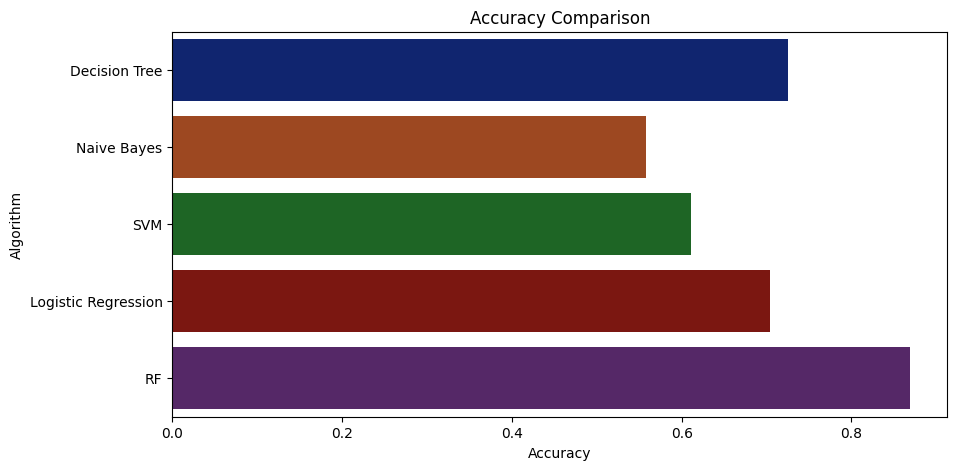

In [88]:
plt.figure(figsize=[10,5],dpi = 100)
plt.title('Accuracy Comparison')
plt.xlabel('Accuracy')
plt.ylabel('Algorithm')
sns.barplot(x = acc,y = model,palette='dark')

In [89]:
accuracy_models = dict(zip(model, acc))
for k, v in accuracy_models.items():
    print (k, '-->', v*100)

Decision Tree --> 72.53027405991077
Naive Bayes --> 55.831739961759084
SVM --> 61.12173358827279
Logistic Regression --> 70.42702358189929
RF --> 86.93435309114086


In [90]:
features

,tcp_packets,dist_port_tcp,external_ips,vulume_bytes,avg_local_pkt_rate,avg_remote_pkt_rate,dns_query_times
0,36,6,3,1330,0,0,3
1,117,0,9,3609,0,0,11
2,196,0,6,3656,0,0,9
3,6,0,1,256,0,0,1
4,6,0,1,251,0,0,1
...,...,...,...,...,...,...,...
7840,0,0,0,0,0,0,2
7841,4,4,1,13,0,0,1
7842,0,0,0,0,0,0,2
7843,0,0,0,0,0,0,2


## Making a prediction

In [91]:
data = np.array([[0,0,0,0,0,0,2]])
prediction = RF.predict(data)
if prediction =="malicious":
    print("NETWROK HAS TRAFFIC")
else :
    print("NO NETWORK TRAFFIC")

NETWROK HAS TRAFFIC


In [93]:
data = np.array([[1,1,1,1,1,1,2]])
prediction = RF.predict(data)
if prediction =="malicious":
    print("NETWROK HAS TRAFFIC")
else :
    print("NO NETWORK TRAFFIC")

NO NETWORK TRAFFIC
